# 09: Wavelet Multiresolution & Spectro-Temporal Modulation Forensics

## 1. Research Scope & Objectives
This notebook evaluates Continuous Wavelet Transform (CWT), Discrete Wavelet Transform (DWT) subband energy distributions, and 2D Spectro-Temporal Modulation Spectrograms to expose localized transient vocoder synthesis glitches.

### Mathematical Formulations
Continuous Wavelet Transform:
$$W(a, b) = \frac{1}{\sqrt{|a|}}\int_{-\infty}^{\infty} x(t) \psi^*\left(\frac{t - b}{a}\right) dt$$
Spectro-Temporal Modulation Transform:
$$\mathcal{M}(\omega_t, \omega_f) = \mathcal{F}_{2D}\{|X(t, f)|\}$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.signal as signal, librosa
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Continuous Wavelet Transform (CWT) Scalogram Forensics
We apply Ricker / Mexican Hat wavelets to capture high-frequency localized energy transitions.

In [2]:
sample_bon = df[df.key == "bonafide"].iloc[0]["file_path"]
sample_spf = df[df.key == "spoof"].iloc[0]["file_path"]

y_b, sr = sf.read(sample_bon)
y_s, _ = sf.read(sample_spf)

widths = np.arange(1, 64)
cwt_b = signal.cwt(y_b[1000:5000], signal.ricker, widths)
cwt_s = signal.cwt(y_s[1000:5000], signal.ricker, widths)

C:\Users\tamimystic\AppData\Local\Temp\ipykernel_18040\1773611775.py:8: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  cwt_b = signal.cwt(y_b[1000:5000], signal.ricker, widths)
C:\Users\tamimystic\AppData\Local\Temp\ipykernel_18040\1773611775.py:9: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  cwt_s = signal.cwt(y_s[1000:5000], signal.ricker, widths)


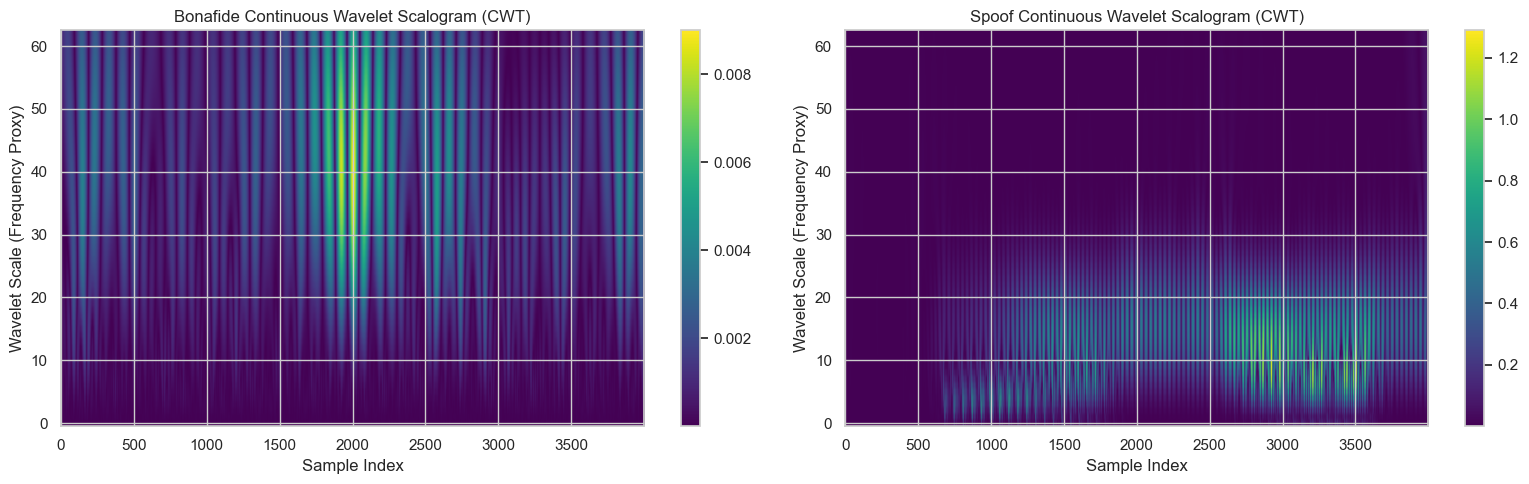

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
im1 = axes[0].imshow(np.abs(cwt_b), aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Bonafide Continuous Wavelet Scalogram (CWT)")
axes[0].set_ylabel("Wavelet Scale (Frequency Proxy)")
axes[0].set_xlabel("Sample Index")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(np.abs(cwt_s), aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Spoof Continuous Wavelet Scalogram (CWT)")
axes[1].set_ylabel("Wavelet Scale (Frequency Proxy)")
axes[1].set_xlabel("Sample Index")
fig.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

## 3. 2D Spectro-Temporal Modulation Spectrograms
2D FFT over time-frequency magnitude maps characterizes temporal rhythm and spectral modulation velocity.

In [4]:
S_b = np.abs(librosa.stft(y_b, n_fft=512, hop_length=256))
S_s = np.abs(librosa.stft(y_s, n_fft=512, hop_length=256))

mod_b = np.abs(np.fft.fftshift(np.fft.fft2(S_b)))
mod_s = np.abs(np.fft.fftshift(np.fft.fft2(S_s)))

mod_b_db = 20 * np.log10(mod_b + 1e-6)
mod_s_db = 20 * np.log10(mod_s + 1e-6)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


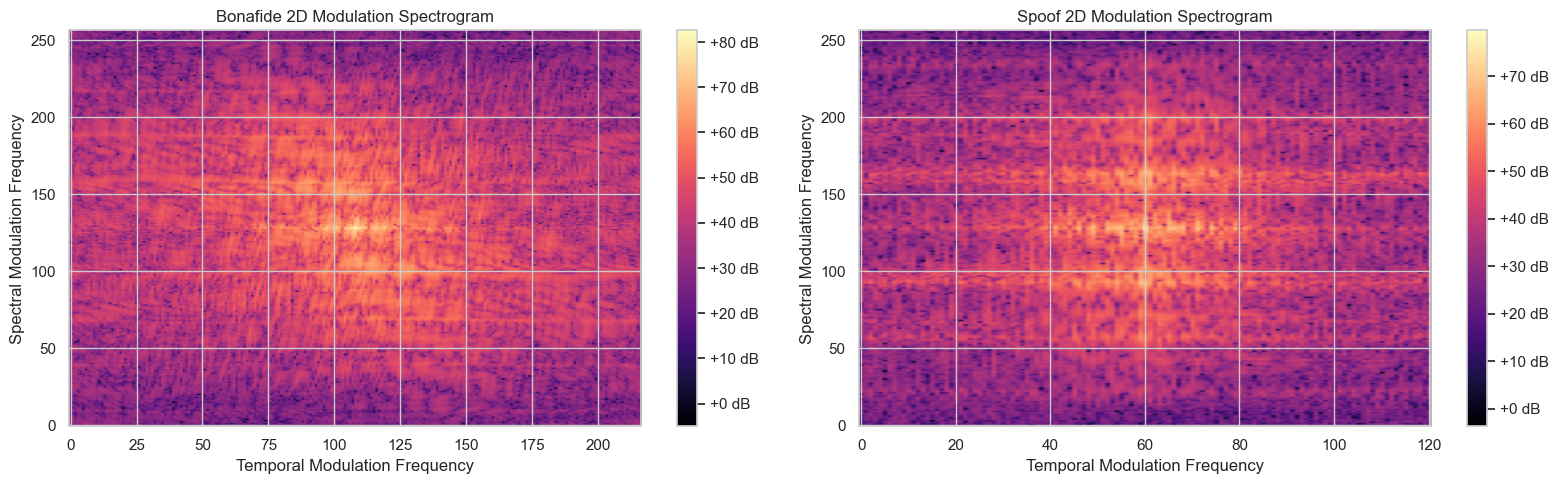

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
im1 = axes[0].imshow(mod_b_db, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("Bonafide 2D Modulation Spectrogram")
axes[0].set_xlabel("Temporal Modulation Frequency")
axes[0].set_ylabel("Spectral Modulation Frequency")
fig.colorbar(im1, ax=axes[0], format="%+2.0f dB")

im2 = axes[1].imshow(mod_s_db, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Spoof 2D Modulation Spectrogram")
axes[1].set_xlabel("Temporal Modulation Frequency")
axes[1].set_ylabel("Spectral Modulation Frequency")
fig.colorbar(im2, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()